In [23]:
# Аналитика
import pandas as pd
#Визуализация
import matplotlib.pyplot as plt
import seaborn as sns

# ML
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
import joblib
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import confusion_matrix
#MLOps
import mlflow
#Системные пакеты

from dotenv import load_dotenv
load_dotenv()

True

In [24]:
path_train = '../data/raw/full.csv'

try:
		data = pd.read_csv(path_train)
		print(f"Успешно загружен датасет: {data.shape}")
except:
		print(f"Файл не найден: {path_train}")


Успешно загружен датасет: (1309, 21)


In [25]:
data.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,...,Embarked,WikiId,Name_wiki,Age_wiki,Hometown,Boarded,Destination,Lifeboat,Body,Class
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,...,S,691.0,"Braund, Mr. Owen Harris",22.0,"Bridgerule, Devon, England",Southampton,"Qu'Appelle Valley, Saskatchewan, Canada",NaN,NaN,3.0
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,...,C,90.0,"Cumings, Mrs. Florence Briggs (née Thayer)",35.0,"New York, New York, US",Cherbourg,"New York, New York, US",4,NaN,1.0
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,...,S,865.0,"Heikkinen, Miss Laina",26.0,"Jyväskylä, Finland",Southampton,New York City,14?,NaN,3.0
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,...,S,127.0,"Futrelle, Mrs. Lily May (née Peel)",35.0,"Scituate, Massachusetts, US",Southampton,"Scituate, Massachusetts, US",D,NaN,1.0
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,...,S,627.0,"Allen, Mr. William Henry",35.0,"Birmingham, West Midlands, England",Southampton,New York City,NaN,NaN,3.0


In [26]:
data.shape

(1309, 21)

<Axes: xlabel='Survived', ylabel='count'>

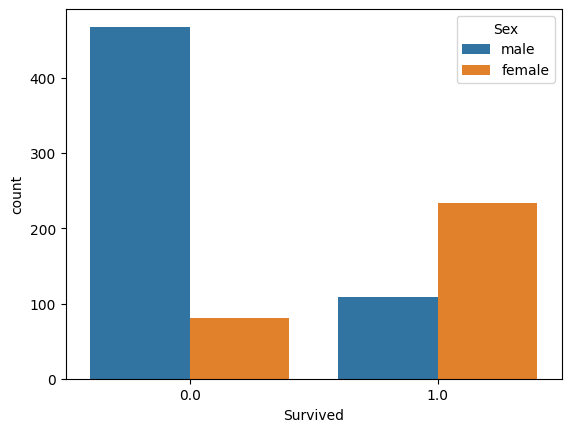

In [27]:
sns.countplot(x='Survived', hue='Sex', data=data)

<Axes: xlabel='Survived', ylabel='count'>

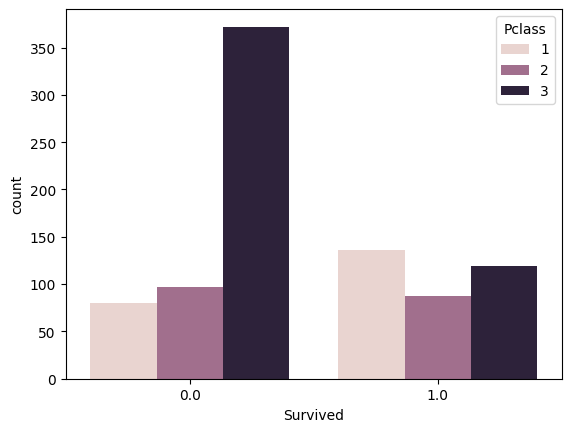

In [28]:
sns.countplot(x='Survived', hue='Pclass', data=data)

<Axes: ylabel='Frequency'>

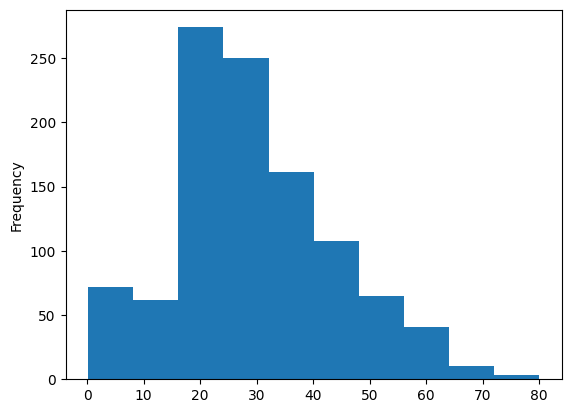

In [29]:
data['Age'].plot.hist()

In [30]:
data.isnull().sum()

PassengerId       0
Survived        418
Pclass            0
Name              0
Sex               0
Age             263
SibSp             0
Parch             0
Ticket            0
Fare              1
Cabin          1014
Embarked          2
WikiId            5
Name_wiki         5
Age_wiki          7
Hometown          5
Boarded           5
Destination       5
Lifeboat        807
Body           1179
Class             5
dtype: int64

In [31]:
data.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,...,Embarked,WikiId,Name_wiki,Age_wiki,Hometown,Boarded,Destination,Lifeboat,Body,Class
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,...,S,691.0,"Braund, Mr. Owen Harris",22.0,"Bridgerule, Devon, England",Southampton,"Qu'Appelle Valley, Saskatchewan, Canada",NaN,NaN,3.0
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,...,C,90.0,"Cumings, Mrs. Florence Briggs (née Thayer)",35.0,"New York, New York, US",Cherbourg,"New York, New York, US",4,NaN,1.0
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,...,S,865.0,"Heikkinen, Miss Laina",26.0,"Jyväskylä, Finland",Southampton,New York City,14?,NaN,3.0
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,...,S,127.0,"Futrelle, Mrs. Lily May (née Peel)",35.0,"Scituate, Massachusetts, US",Southampton,"Scituate, Massachusetts, US",D,NaN,1.0
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,...,S,627.0,"Allen, Mr. William Henry",35.0,"Birmingham, West Midlands, England",Southampton,New York City,NaN,NaN,3.0


In [32]:
data = data.drop(['Name_wiki','Name', 'Destination','Hometown','Ticket','PassengerId','WikiId','Boarded','Body','Age_wiki','Lifeboat','Cabin'], axis = 1)

In [33]:
embarked = pd.get_dummies(
	data['Embarked'],
).astype(float)

data = pd.concat([data,embarked],axis=1)
data = data.drop('Embarked', axis=1)

In [34]:
data = data.dropna()
data = data.drop_duplicates()

In [35]:
print((data.isna().sum() / len(data)) * 100)

Survived    0.0
Pclass      0.0
Sex         0.0
Age         0.0
SibSp       0.0
Parch       0.0
Fare        0.0
Class       0.0
C           0.0
Q           0.0
S           0.0
dtype: float64


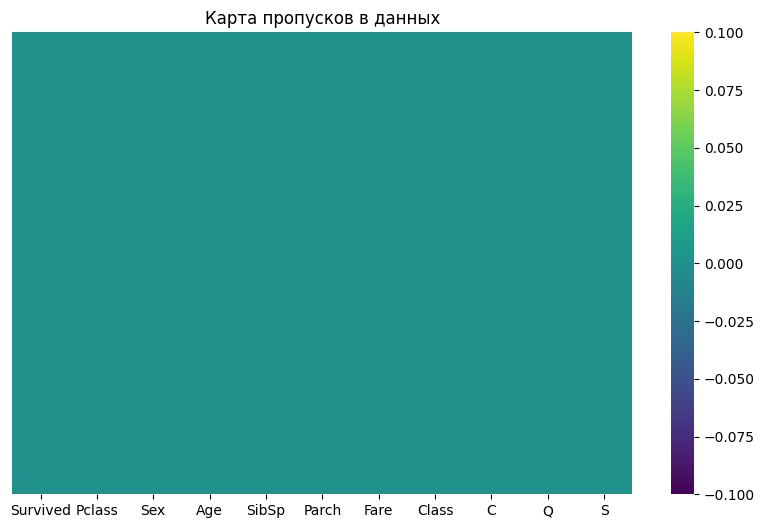

In [36]:
plt.figure(figsize=(10, 6))
sns.heatmap(data.isnull(), cbar=True, yticklabels=False, cmap='viridis')
plt.title('Карта пропусков в данных')
plt.show()

In [37]:
data.head(5)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Class,C,Q,S
0,0.0,3,male,22.0,1,0,7.2500,3.0,0.0,0.0,1.0
1,1.0,1,female,38.0,1,0,71.2833,1.0,1.0,0.0,0.0
2,1.0,3,female,26.0,0,0,7.9250,3.0,0.0,0.0,1.0
3,1.0,1,female,35.0,1,0,53.1000,1.0,0.0,0.0,1.0
4,0.0,3,male,35.0,0,0,8.0500,3.0,0.0,0.0,1.0


In [38]:
print(data.select_dtypes(include=['object']).columns.tolist())

['Sex']


In [39]:
x = data.drop('Survived', axis = 1)
y = data['Survived']

In [40]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.3,random_state=42,stratify=y)

In [41]:
try:
    model_load = joblib.load("./model.pkl")
    print("Модель загружена из model.pkl")
except FileNotFoundError:
    print("Файл model.pkl не найден, модель будет обучена заново")

Файл model.pkl не найден, модель будет обучена заново


In [42]:

scaler = StandardScaler()
numeric_features = ['Fare','Class','SibSp','Age']
categorical_features = ['Sex']
numeric_transform = Pipeline(steps=[
	('imputer', SimpleImputer(strategy = 'median')),
	('scaler',scaler),
	
])

categorical_transform = Pipeline(steps=[
	('imputer', SimpleImputer(
		strategy = 'constant',
		fill_value='Missing')),
		('onehot',OneHotEncoder(handle_unknown='ignore'))
])
preprocessor = ColumnTransformer(
	[('num',numeric_transform,numeric_features),
	('cat', categorical_transform,categorical_features)]
)

In [43]:
try:
    if mlflow.active_run():
        mlflow.end_run()
except Exception as e:
    print(f"Предупреждение: не удалось завершить предыдущий запуск: {e}")

In [44]:
with mlflow.start_run(run_name = 'Hyperparameter'):
	model = LogisticRegression(max_iter=1000, random_state=43)
	pipeline = Pipeline(steps=[
		('preprocessor', preprocessor),
		('model', model)
	])
	
	param_grid = [
		{  
      'model__l1_ratio': [1.0],
      'model__C': [0.1, 1, 10],
      'model__solver': ['liblinear', 'saga']
    },
    {  
      'model__l1_ratio': [0.0],
      'model__C': [0.1, 1, 10],
      'model__solver': ['lbfgs', 'liblinear', 'saga']
    },
    {  
      'model__l1_ratio': [0.1, 0.5, 0.9],
      'model__C': [0.1, 1, 10],
      'model__solver': ['saga']  
    }
	]

	grid_model = GridSearchCV(
		pipeline,
		param_grid = param_grid,
		cv = 5,
		scoring='f1_macro'
	)


	grid_model.fit(x_train, y_train)
	predict = grid_model.predict(x_test)
	report = classification_report(y_test,predict,output_dict=True)

	precision = report['macro avg']['precision']
	f1_score = report['macro avg']['f1-score']
	recall = report['macro avg']['recall']
	accuracy = report['accuracy']
	
	mlflow.log_params(grid_model.best_params_)
	mlflow.log_metric('f1_score', grid_model.best_score_)
	mlflow.log_metric('test_recall', recall)
	mlflow.log_metric('test_accuracy', accuracy)
	mlflow.log_metric('test_precision', precision)
	mlflow.set_tracking_uri("sqlite:///db_models/mlflow.db")
	
	artifact_path = "./classification_report.txt"
	with open(artifact_path, 'w') as f:
		f.write(classification_report(y_test, predict))
	mlflow.log_artifact(artifact_path)
	mlflow.sklearn.log_model(
		grid_model.best_estimator_, 
		'best_model',
		registered_model_name='LogisticRegressionBest'
		)


2026/04/08 14:30:19 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/08 14:30:19 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Successfully registered model 'LogisticRegressionBest'.
Created version '1' of model 'LogisticRegressionBest'.


In [45]:
print("Текущий URI трекера:", mlflow.get_tracking_uri())

Текущий URI трекера: sqlite:///db_models/mlflow.db


In [46]:
joblib.dump(grid_model.best_estimator_, 'model.pkl')


['model.pkl']

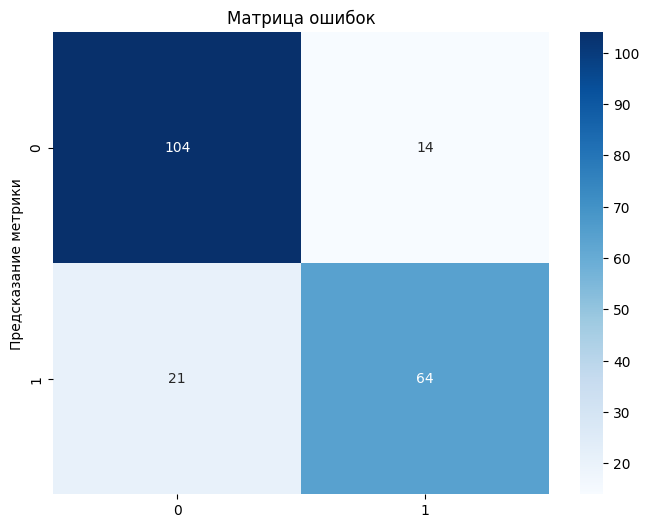

In [47]:
cm = confusion_matrix(y_test,predict)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Матрица ошибок')
plt.ylabel('Истинные метки')
plt.ylabel('Предсказание метрики')
plt.savefig('confusion_matrix.png')
mlflow.log_artifact('confusion_matrix.png')
plt.show()